#**WEEK 3:**


> *The Lorenz System and Strange Attractors*



##**THE LORENZ ATTRACTOR:**
*from discrete maps to continuous flows in 3 dimensions*

##**INTRODUCTION:**

After studying chaos in the one-dimensional logistic map using bifurcations and the Lyapunov exponent, the next step is to investigate whether the same principles apply to continuous-time systems. This is done using the Lorenz system which uses three non-linear differential equations to visualise chaos.




###**1. What is the Lorenz Attractor?**:
The Lorenz attractor is one of the most famous examples in chaos theory. It arises from the Lorenz system, a set of three nonlinear differential equations
developed by Edward Lorenz in 1963 while studying atmospheric convection and weather prediction. At the classical parameter values $σ=10, β=8/3, ρ=28$, the system produces a distinctive butterfly-shaped trajectory known as a strange attractor. Although the trajectory remains confined to a bounded region of space, it never repeats exactly and exhibits sensitive dependence on initial conditions, meaning that even tiny differences in starting points eventually lead to dramatically different paths. This makes the Lorenz attractor a fundamental model for understanding deterministic chaos.

###**2. The three equations:**
The Lorenz system consists of three coupled nonlinear differential equations:

$$
\frac{dx}{dt} = \sigma (y - x)
$$

$$
\frac{dy}{dt} = x(\rho - z) - y
$$

$$
\frac{dz}{dt} = xy - \beta z
$$

where:

- $x$, $y$, and $z$ are the three state variables.
- σ, β and ρ are the three main parameters

Throughout this project, the classical Lorenz parameters are used:

$$
\sigma = 10, \qquad
\beta = \frac{8}{3}, \qquad
\rho = 28.
$$
These are the standard parameters at which the Lorenz System showcases its famous chaotic behavior.

###**3. Why cant we solve these like the Logistic Map?**
The three equations do not tell us the next co-ordinate as simply as the logistic map, infact, they only inform us about the rate of change for each variable. Hence, to know the next position, we use a numerical approximation method known as the RK-4 which is a means to numerically integrate the equations to estimate the solution.

###**4. Why is RK-4 used?**
There are a number of methods for numerical integration and estimation of the next position, however the RK-4 is the most accurate one. This is because other means like the Eueler Method only 'sample' the slope once, whereas the RK-4 sampke it four times, and combine sthese into a weighted average which is a far more accurate estimate of the next point compared to only sampling the slope once. This is because we cannot estimate the derivative remains the same throughout for the Lorenz system.

###**5. Simulating the attractor using these equations:**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# Classical Lorenz parameters
sigma = 10
beta = 8/3
rho = 28

# Lorenz system
def lorenz(t, state):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]
# Initial condition
initial_state = [1, 1, 1]

# Time interval
t_start = 0
t_end = 40

# Time points where solution is stored
t = np.linspace(t_start, t_end, 30000)

# Solve the system
solution = solve_ivp(
    lorenz,
    [t_start, t_end],
    initial_state,
    t_eval=t
)

# Extract x, y and z
x = solution.y[0]
y = solution.y[1]
z = solution.y[2]


import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

line, = ax.plot([], [], [], lw=1)
point, = ax.plot([], [], [], 'ro')

ax.set_xlim(min(x), max(x))
ax.set_ylim(min(y), max(y))
ax.set_zlim(min(z), max(z))

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

def update(frame):
    line.set_data(x[:frame], y[:frame])
    line.set_3d_properties(z[:frame])

    point.set_data([x[frame]], [y[frame]])
    point.set_3d_properties([z[frame]])

    return line, point

ani = FuncAnimation(
    fig,
    update,
    frames=range(0, len(x), 20),
    interval=20,
    blit=True
)

HTML(ani.to_jshtml())

### **5. Simulating the Divergence of Two Nearby Trajectories and the Lyapunov Exponent**

One of the defining characteristics of chaotic systems is **sensitive dependence on initial conditions**. Two trajectories that begin extremely close together initially follow almost identical paths, but gradually diverge over time despite being governed by the same deterministic equations.

The rate of this separation is quantified by the **Lyapunov exponent**,

$$
d(t)\approx d_0e^{\lambda t},
$$

where:

- $d_0$ is the initial separation,
- $d(t)$ is the separation after time $t$,
- $\lambda$ is the Lyapunov exponent.

If $\lambda>0$, nearby trajectories separate exponentially, indicating chaotic behaviour. If $\lambda<0$, trajectories converge, while $\lambda=0$ is the boundary of stability.

We explore this by plotting two nearby trajectories (divergence vs time) to estimate the Lyapunov exponent in this continuous setting.


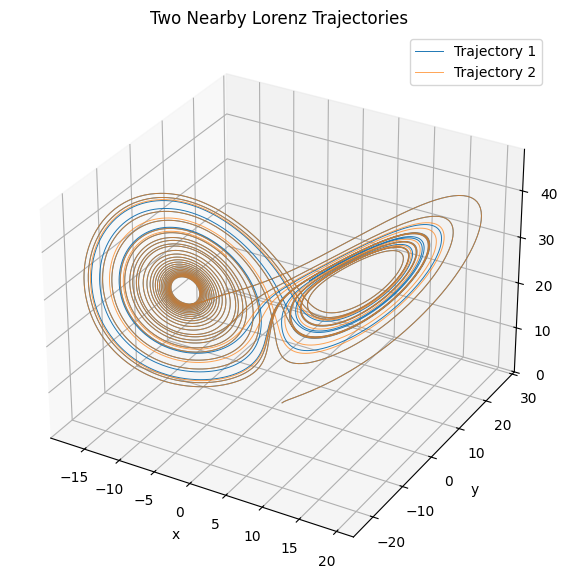

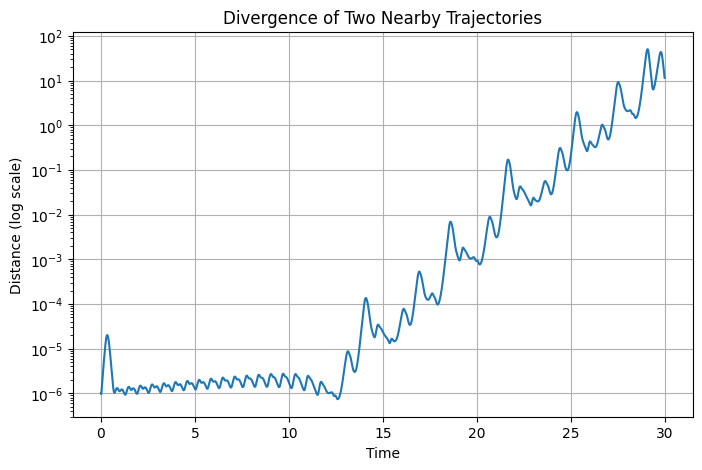

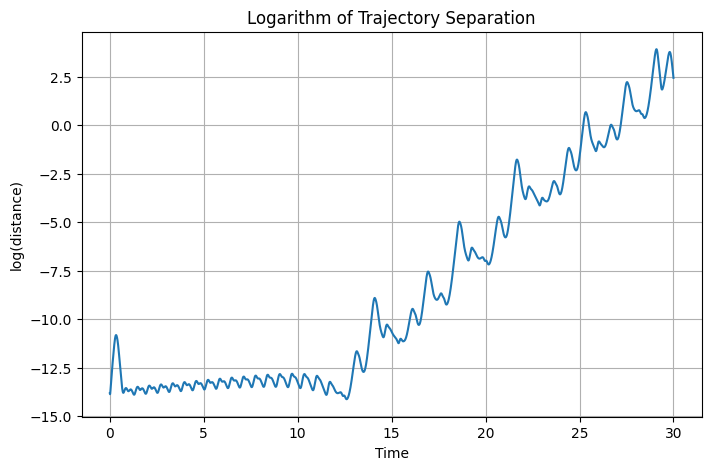

Estimated Lyapunov Exponent ≈ 0.925


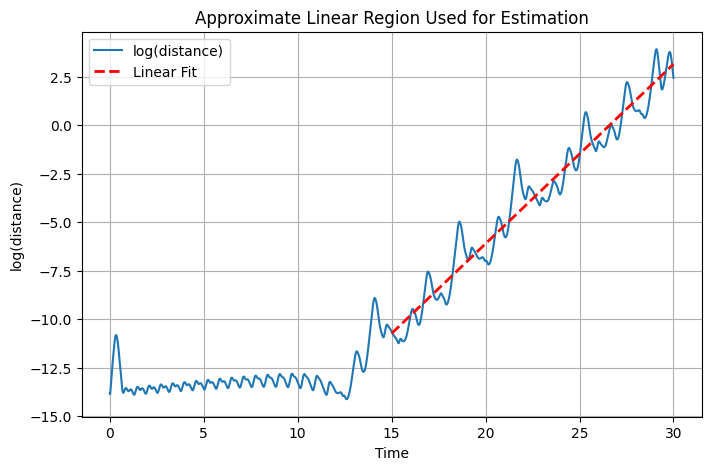

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================
# Classical Lorenz Parameters
# =====================================================

sigma = 10
beta = 8/3
rho = 28

# =====================================================
# Lorenz System
# =====================================================

def lorenz(t, state):
    x, y, z = state

    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z

    return [dxdt, dydt, dzdt]

# =====================================================
# Simulation Settings
# =====================================================

t_start = 0
t_end = 30

t = np.linspace(t_start, t_end, 8000)

# =====================================================
# Nearly Identical Initial Conditions
# =====================================================

initial_state1 = [1.0, 1.0, 1.0]
initial_state2 = [1.000001, 1.0, 1.0]

# =====================================================
# Solve Both Trajectories
# =====================================================

solution1 = solve_ivp(
    lorenz,
    [t_start, t_end],
    initial_state1,
    t_eval=t,
    rtol=1e-10,
    atol=1e-12
)

solution2 = solve_ivp(
    lorenz,
    [t_start, t_end],
    initial_state2,
    t_eval=t,
    rtol=1e-10,
    atol=1e-12
)

# =====================================================
# Extract Coordinates
# =====================================================

x1, y1, z1 = solution1.y
x2, y2, z2 = solution2.y

# =====================================================
# Plot Two Nearby Trajectories
# =====================================================

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1, y1, z1, lw=0.7, label="Trajectory 1")
ax.plot(x2, y2, z2, lw=0.7, alpha=0.7, label="Trajectory 2")

ax.set_title("Two Nearby Lorenz Trajectories")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()

plt.show()

# =====================================================
# Compute Separation
# =====================================================

distance = np.sqrt(
    (x2-x1)**2 +
    (y2-y1)**2 +
    (z2-z1)**2
)

distance = np.maximum(distance,1e-15)

# =====================================================
# Divergence Plot
# =====================================================

plt.figure(figsize=(8,5))

plt.semilogy(t,distance)

plt.title("Divergence of Two Nearby Trajectories")
plt.xlabel("Time")
plt.ylabel("Distance (log scale)")
plt.grid(True)

plt.show()

# =====================================================
# Plot log(distance)
# =====================================================

log_distance = np.log(distance)

plt.figure(figsize=(8,5))

plt.plot(t,log_distance)

plt.title("Logarithm of Trajectory Separation")
plt.xlabel("Time")
plt.ylabel("log(distance)")
plt.grid(True)

plt.show()

# =====================================================
# Estimate Lyapunov Exponent
# =====================================================
#
# IMPORTANT:
# Look at the log(distance) graph.
# Fit ONLY the region that looks approximately straight.
#
# These values are an initial guess and may be adjusted.
#
# =====================================================

fit_start = np.searchsorted(t,15)
fit_end   = np.searchsorted(t,30)

coeffs = np.polyfit(
    t[fit_start:fit_end],
    log_distance[fit_start:fit_end],
    1
)

lyapunov = coeffs[0]

print(f"Estimated Lyapunov Exponent ≈ {lyapunov:.3f}")

# =====================================================
# Show Linear Fit
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(t,log_distance,label="log(distance)")

plt.plot(
    t[fit_start:fit_end],
    np.polyval(coeffs,t[fit_start:fit_end]),
    'r--',
    linewidth=2,
    label="Linear Fit"
)

plt.xlabel("Time")
plt.ylabel("log(distance)")
plt.title("Approximate Linear Region Used for Estimation")

plt.legend()
plt.grid(True)

plt.show()

### **Analysis:**

The estimated Lyapunov exponent is positive, confirming that nearby trajectories diverge exponentially. This provides quantitative evidence that the Lorenz system exhibits deterministic chaos. Although the governing equations are completely deterministic, tiny differences in initial conditions eventually produce significantly different trajectories, making long-term prediction impossible.

###**6. The Lorenz Map:**

The Lorenz map provides a simple one-dimensional representation of the Lorenz attractor. Instead of plotting the full three-dimensional trajectory, we record the successive local maxima of the variable $z(t)$.

Plotting each maximum against the following one,

$$
z_n \rightarrow z_{n+1},
$$

reveals an underlying deterministic structure hidden within the seemingly irregular motion. The Lorenz map acts as a bridge between the continuous Lorenz system and the one-dimensional iterative maps studied previously, such as the logistic map.


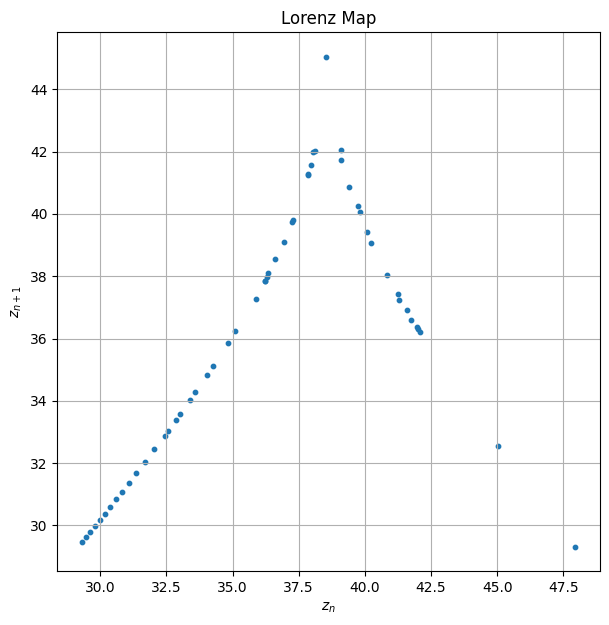

In [ ]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(z)

zmax = z[peaks]
plt.figure(figsize=(7,7))

plt.scatter(
    zmax[:-1],
    zmax[1:],
    s=10
)

plt.xlabel(r"$z_n$")

plt.ylabel(r"$z_{n+1}$")

plt.title("Lorenz Map")

plt.grid(True)

plt.show()


### **Interpretation**

Unlike a random scatter plot, the Lorenz map reveals that the system follows a deterministic relationship between successive maxima. Although the sequence of peaks appears irregular, it is constrained to a well-defined curve. This demonstrates how a continuous chaotic system can be represented using a one-dimensional return map, linking the Lorenz system to the logistic map studied previously.




###**7. Eigenvalues and Stability:**

Before simulating the Lorenz system, its fixed points can be analysed using the Jacobian matrix. The eigenvalues of the Jacobian determine the local stability of each equilibrium point.

- If all eigenvalues have negative real parts, nearby trajectories converge to the fixed point.
- If at least one eigenvalue has a positive real part, nearby trajectories diverge, making the fixed point unstable.
- Changes in the signs of the eigenvalues correspond to bifurcations, where the qualitative behaviour of the system changes.

Eigenvalues describe the **local behaviour near equilibrium points**, while numerical integration reveals the **global dynamics** of the system, including the butterfly attractor. They therefore explain when stability is lost but do not generate the attractor itself.

###**8.  What makes the Lorenz attractor "strange"?**

A **strange attractor** is strange in three specific senses, all visible in
this week's plots:

1. **Bounded**: despite never repeating and never settling down, the trajectory
   never escapes to infinity. It stays confined within a finite region of phase
   space (the two "wings" of the butterfly). Everything gets pulled onto a thin, zero-volume set which is the
   attractor itself.

2. **Non-periodic**: the trajectory never exactly retraces its own path. If you
   look at the Lorenz map above, the fact that points don't collapse onto a
   finite set of discrete values (as they would for a periodic orbit) is evidence
   of this — the map is a continuous curve, implying infinitely many distinct
   values of z at the maxima.

3. **Sensitive to initial conditions**: the divergence plot is the direct
   evidence. Two trajectories starting a tiny distance apart diverge
   *exponentially*, not linearly. The estimated Lyapunov exponent (λ ≈ 0.9) quantifies this: it's
   the average exponential rate at which nearby trajectories separate. A positive
   λ is the indicator of chaos — it means a small measurement error
   grows to swamp any long-term prediction, even though the system is fully
   deterministic and governed by only three simple equations.

Put together: the attractor is a bounded object on which motion never repeats and is exponentially unpredictable in
detail — while remaining statistically predictable in shape. That combination is
what "strange" refers to.

#**WEEK 4**:


>*Stretching and folding in chaotic systems and a practical application*





##**INTRODUCTION: The stretch and Fold Mechanism**

Chaos in arises from two complementary processes known as stretching and folding. Although these systems are defined by fixed and deterministic mathematical equations, the repeated action of stretching and folding is the reason why their longterm behaviour is extremely difficult to predict.


###**1. STRETCHING:**
Stretching is the proess by which two nearby trajectories diverge and move further and further apart as the system progresses. Even an infinitesimally small difference between two starting points grows over time, making their future behaviour increasingly different and difficult to predict. This is known as sensitive dependence on initial conditions and is one of the defining characteristics of chaos.

The separation between the trajectories is defined by $$
d(t) ≈ d_0e^{λt} $$
where


*   $d_0$ is the initial separation
*   $d(t)$ is the separation after time t,
*   λ is the Lyapunov Exponent.

A positive Lyapunov exponent indicates exponential divergence, meaning that even extremely small uncertainties in the initial conditions eventually lead to completely different future trajectories.

### **2. FOLDING:**
If stretching were the only process occurring, trajectories would continue moving farther apart indefinitely and eventually leave the system. However, chaotic systems remain bounded because the flow also folds trajectories back into the same finite region of space. This prevents trajectories from escaping while preserving the complexity created by stretching.

In the Lorenz system, trajectories repeatedly move around one wing of the butterfly before curving back toward the centre and switching to the opposite wing. This continual redirection keeps the motion confined while allowing stretching to occur repeatedly.

The interaction between stretching and folding creates a bounded yet highly complex trajectory known as a strange attractor.

### **3. The Baker's Map:**
The Baker's Map is one of the simplest mathematical models used to illustrate the stretch and fold mechanism

**Step 1 — Initial Square**

We begin with a **unit square**, representing all possible initial conditions of a system. Every point inside the square corresponds to a unique starting state.

<div align="center">

🟥🟥🟥🟥🟦🟦🟦🟦<br>
🟥🟥🟥🟥🟦🟦🟦🟦<br>
🟥🟥🟥🟥🟦🟦🟦🟦<br>
🟥🟥🟥🟥🟦🟦🟦🟦

</div>

Initially, nearby points remain close together, and the square has a simple, ordered structure.

**Step 2 — Stretch**

The square is stretched horizontally and compressed vertically. During this stage, nearby points begin moving farther apart.

<div align="center">

🟥🟥🟥🟥🟥🟥🟥🟥🟦🟦🟦🟦🟦🟦🟦🟦

</div>

Stretching increases the separation between neighbouring points. In chaotic systems, this corresponds to **sensitive dependence on initial conditions**, where tiny differences between trajectories grow over time.

**Step 3 — Cut and Fold (Stack)**

The stretched rectangle is divided into two equal halves. One half is then placed on top of the other, restoring the original square while rearranging the positions of nearby points.

<div align="center">

<table>
<tr>

<td align="center">

<b>Before Folding</b>

🟥🟥🟥🟥🟥🟥🟥🟥🟦🟦🟦🟦🟦🟦🟦🟦

</td>

<td width="60"></td>

<td align="center">

<b>After Folding</b>

🟥🟥🟥🟥🟥🟥🟥🟥<br>
🟦🟦🟦🟦🟦🟦🟦🟦

</td>

</tr>
</table>

</div>

Folding prevents the points from spreading indefinitely by returning them to the original bounded region. Although the square regains its original shape, neighbouring points have been rearranged.

**Step 4 — Repeat**

The stretch-and-fold process is repeated continuously.

<div align="center">

Initial Square

⬇️

Stretch

⬇️

Cut

⬇️

Fold

⬇️

Repeat

</div>

With every iteration, nearby points become increasingly separated while the overall square remains bounded. This repeated stretching and folding produces progressively finer patterns and efficient mixing.



##**4. Connection to the Lorenz Attractor**

The Baker's Map is a simplified, discrete model of the same mechanism found in continuous chaotic systems such as the Lorenz attractor.

- **Stretching** causes nearby trajectories to separate exponentially, producing sensitive dependence on initial conditions.
- **Folding** prevents trajectories from escaping by returning them to a bounded region.
- Repeating these two processes indefinitely generates complex, non-periodic motion while remaining entirely deterministic.

Although the Lorenz system does not literally cut or stack trajectories, its continuous flow repeatedly stretches nearby trajectories apart before smoothly folding them back into the butterfly-shaped attractor. The Baker's Map therefore provides an intuitive geometric explanation for one of the fundamental mechanisms responsible for deterministic chaos.

###**5.  Why Stretching and Folding Produce Chaos:**

Neither stretching nor folding alone is sufficient to generate chaos.

Stretching without folding would cause trajectories to escape to infinity.
Folding without stretching would simply compress trajectories together without creating complexity.

Chaos emerges only when these two processes act together.

Stretching continually amplifies tiny differences between nearby trajectories, making long-term prediction increasingly difficult. Folding simultaneously keeps all trajectories confined within a finite region, allowing the stretching process to occur repeatedly.

This repeated cycle produces motion that is deterministic, bounded, non-periodic, and highly sensitive to initial conditions—the defining characteristics of chaotic systems.



---

## **Conclusion**
The stretch-and-fold mechanism provides an intuitive explanation for deterministic chaos. Rather than relying on randomness, chaotic systems generate complex behaviour through the continual repetition of two simple geometric processes. Stretching amplifies tiny differences between neighbouring trajectories, while folding keeps those trajectories confined within a bounded region. The Lorenz attractor demonstrates this mechanism in a smooth continuous flow, whereas the Baker's Map provides a simplified discrete illustration of the same underlying idea. Together, these models explain why deterministic systems can exhibit behaviour that appears random while remaining entirely governed by fixed mathematical equations.